# 7. Visualize
This notebook stores visualization functions and their example uses

In [2]:
import sys
sys.path.append('../src')
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
import numpy as np
import jax
import jax.numpy as jnp
import mrcfile
import matplotlib.pyplot as plt
import napari
from pinn.cryoet_io import open_mrc
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_checkpoint_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
    visualize_z_midslice,
    visualize_zyx_midslice,
    visualize_zyx_midslice_vs_overlay,
    _to_zyx
)
from pinn.utils import assemble_loss_history, initial_loss
from pinn.model import (
    PINN,
    WEIGHT_IN, 
    EPSILON,
    LEARNING_RATE
) 
from pinn.checkpoint_io import (
    _ensure_dir,
    save_params_bytes,
    load_state_bytes,
    save_loss_npz,
    load_loss_npz,
    find_last_state_path,
    load_checkpoint_at_step
)
from pinn.grid import (
    phi_on_cryo_grid_xyz
)
from pinn.train import create_train_state, train_step
print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]
from tqdm.notebook import trange

jax: 0.7.2
devices: [CudaDevice(id=0)]


### Load specific checkpoint

In [3]:
data_dir = "Jake_Cropped"
shape = "74_E1"
ori_data_path = f"../data/{data_dir}/{shape}_normalized_cropped.mrc"
mask_data_path = f"../data/{data_dir}/{shape}_mask_cropped.mrc"
lambda_1 = 100000000
lambda_2 = 800

ori_data = open_mrc(ori_data_path)
mask_data = open_mrc(mask_data_path)

result_shape = "74_E1_normalized_cropped"
checkpoint_dir = os.path.abspath(
    f"../outputs/logs/{result_shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{0.5}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint"
)
checkpoint_data = load_checkpoint_at_step(10000, checkpoint_dir, lambda_1, lambda_2)
state = checkpoint_data["state"]; params = state["params"]
model = PINN()
phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))
phi_xyz, _, (x_axis, y_axis, z_axis) = phi_on_cryo_grid_xyz(phi_fn, ori_data.shape, lo=-1.0, hi=1.0)
phi_zyx = _to_zyx(np.array(phi_xyz))  

Data shape: (45, 329, 350)
Voxel size (angstroms): (0.0, 0.0, 0.0)
Data shape: (45, 329, 350)
Voxel size (angstroms): (0.0, 0.0, 0.0)


#### ZYX Midslice vs Overlay

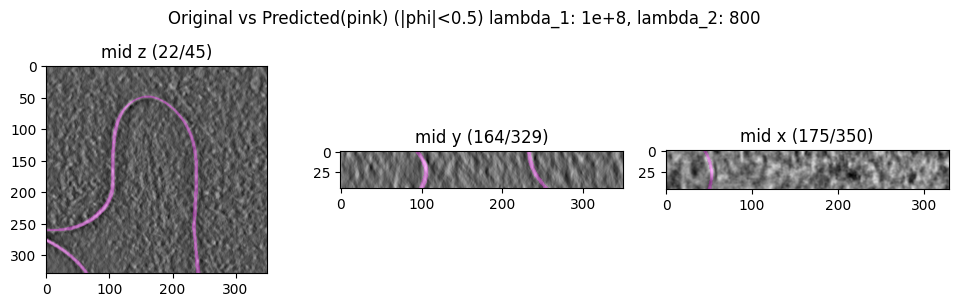

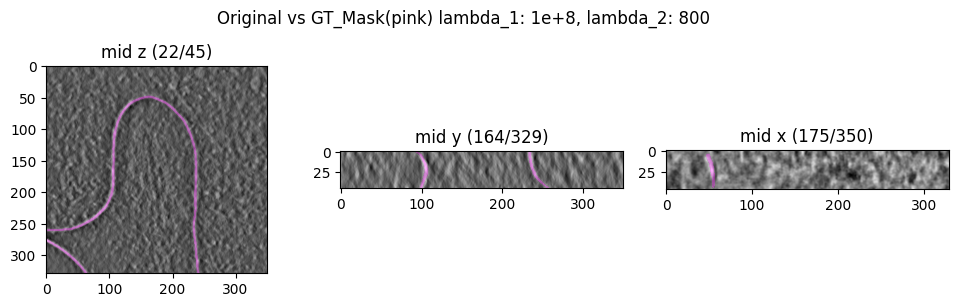

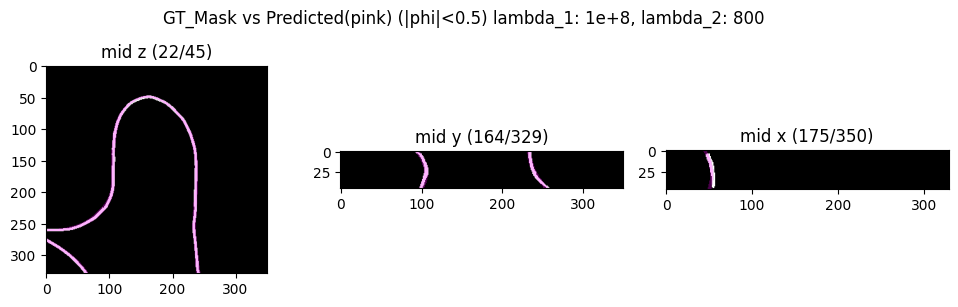

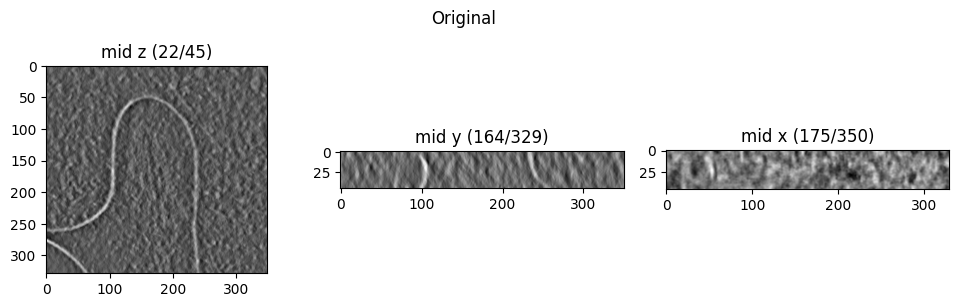

In [4]:
phi_pred = np.where(abs(phi_zyx) < 0.5, 1, 0)
visualize_zyx_midslice_vs_overlay(ori_data, phi_pred, alpha=0.3, title="Original vs Predicted(pink) (|phi|<0.5) lambda_1: 1e+8, lambda_2: 800")
visualize_zyx_midslice_vs_overlay(ori_data, mask_data, alpha=0.3, title="Original vs GT_Mask(pink) lambda_1: 1e+8, lambda_2: 800")
visualize_zyx_midslice_vs_overlay(mask_data, phi_pred, alpha=0.3, title="GT_Mask vs Predicted(pink) (|phi|<0.5) lambda_1: 1e+8, lambda_2: 800")
visualize_zyx_midslice(ori_data, title="Original")

#### 3D Mask vs Prediction

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.ticker import MultipleLocator

def overlay_3d_surfaces_marching_cube(
    pred_mask, gt_mask, overlap_phi_threshold = 0.8, spacing=(1.0, 1.0, 1.0),
    colors=((1, 0, 0, 0.3),   # predicted
            (0, 0, 1, 0.3),   # gt_mask
            (1, 0, 1, 0.3))): # overlay
    """
    pred_mask, gt_mask: (Z, Y, X)
    spacing: (sx, sy, sz)
    """
    assert pred_mask.shape == gt_mask.shape, "Masks must have the same shape (Z, Y, X)."

    # Convert (Z,Y,X) → (X,Y,Z)
    pred_mask = pred_mask.transpose(2, 1, 0)
    gt_mask   = gt_mask.transpose(2, 1, 0)

    X, Y, Z = pred_mask.shape
    sx, sy, sz = spacing

    # Extract surfaces
    pred_verts, pred_faces, _, _ = marching_cubes(pred_mask.astype(np.float32),
                                                  level=0.0, spacing=(sx, sy, sz))
    gt_verts, gt_faces, _, _ = marching_cubes(gt_mask.astype(np.float32),
                                              level=0.9, spacing=(sx, sy, sz))

    # Overlap mask
    overlap = np.logical_and(abs(pred_mask) > overlap_phi_threshold, gt_mask > 0.5).astype(np.float32)
    overlap_present = overlap.any()
    if overlap_present:
        overlap_verts, overlap_faces, _, _ = marching_cubes(overlap, level=0.5, spacing=(sx, sy, sz))

    # ===== Plot =====
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    # predicted
    pred_mesh = Poly3DCollection(pred_verts[pred_faces],
                                 alpha=colors[0][3],
                                 facecolor=colors[0][:3],
                                 edgecolor='none')
    ax.add_collection3d(pred_mesh)

    # gt_mask
    gt_mesh = Poly3DCollection(gt_verts[gt_faces],
                               alpha=colors[1][3],
                               facecolor=colors[1][:3],
                               edgecolor='none')
    ax.add_collection3d(gt_mesh)

    # overlay
    if overlap_present:
        overlay_mesh = Poly3DCollection(overlap_verts[overlap_faces],
                                        alpha=colors[2][3],
                                        facecolor=colors[2][:3],
                                        edgecolor='none')
        ax.add_collection3d(overlay_mesh)

    # ===== Legend patches =====
    patch_pred = Patch(facecolor=colors[0][:3], alpha=colors[0][3], label="predicted")
    patch_gt   = Patch(facecolor=colors[1][:3], alpha=colors[1][3], label="gt_mask")
    
    patches = [patch_pred, patch_gt]

    if overlap_present:
        patch_overlay = Patch(facecolor=colors[2][:3], alpha=colors[2][3], label="overlay")
        patches.append(patch_overlay)

    ax.legend(handles=patches, loc="upper right", fontsize=12)

    # Axes
    ax.set_xlim(0, X * sx)
    ax.set_ylim(0, Y * sy)
    ax.set_zlim(0, Z * sz)
    ax.zaxis.set_major_locator(MultipleLocator(15))

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z", labelpad=10)

    ax.set_box_aspect((X*sx, Y*sy, Z*sz))

    plt.tight_layout()
    plt.show()


In [6]:
phi_pred = np.where(abs(phi_zyx) < 0.5, 1, 0)
mask_data = np.where(mask_data > 0, 1, 0)

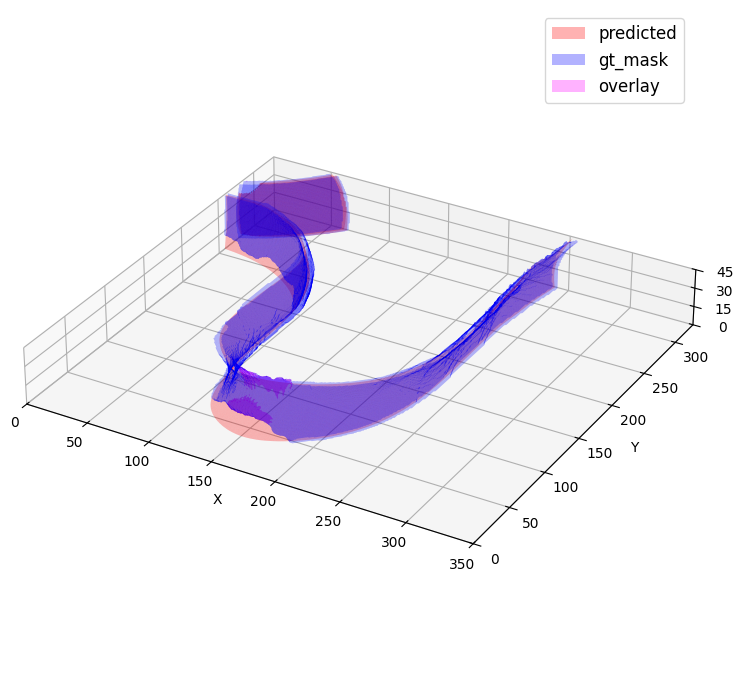

In [14]:
overlay_3d_surfaces_marching_cube(phi_zyx, mask_data)

In [ ]:
import matplotlib.pyplot as plt

def plot_binary_voxels(pred_data, gt_mask):
    Z, Y, X = gt_mask.shape

    fig = plt.figure(figsize=(8,7))
    ax = fig.add_subplot(111, projection="3d")

    # GT mask
    ax.voxels(gt_mask == 1,
              facecolors='blue', edgecolor='k', alpha=0.3)

    # predicted mask
    ax.voxels(abs(pred_data) < 0.5,
              facecolors='red', edgecolor='k', alpha=0.3)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    ax.set_box_aspect((X, Y, Z))  # (X:Y:Z ratio)

    plt.tight_layout()
    plt.show()

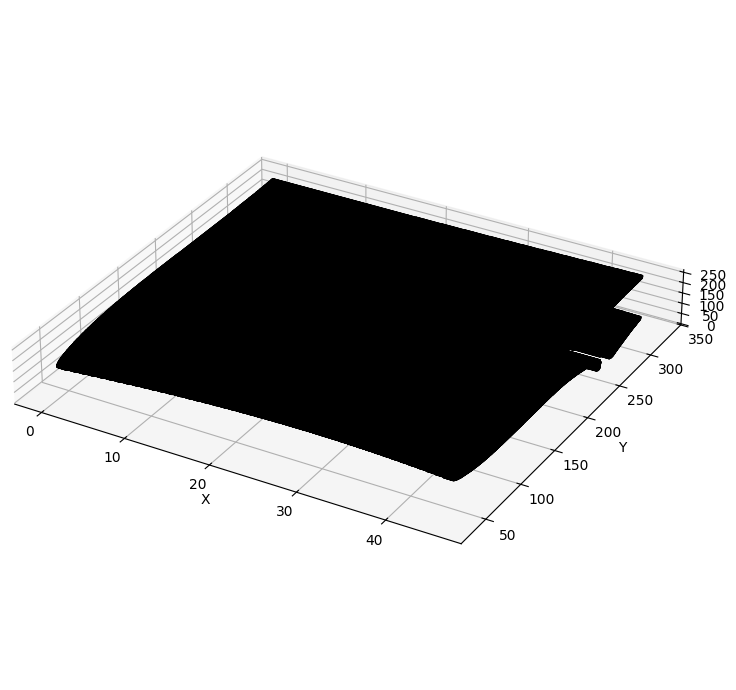

In [17]:
plot_binary_voxels(phi_zyx, mask_data)

##### Aren't sure if the two other 3D visualization methods work.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_binary_voxels(pred_data, gt_mask):
    # ------------------------
    # 1. (Z,Y,X) → (X,Y,Z) transpose
    # ------------------------
    gt_xyz   = gt_mask.transpose(2,1,0)         # (X,Y,Z)
    pred_xyz = (np.abs(pred_data) < 0.5).transpose(2,1,0)  # (X,Y,Z)

    vol = gt_xyz | pred_xyz   # Map existing voxels

    # facecolor array
    facecolors = np.zeros(vol.shape + (4,), dtype=float)

    # Color: pred=red, gt=blue, overlap=purple
    pred_only = pred_xyz & ~gt_xyz
    gt_only   = gt_xyz & ~pred_xyz
    both      = pred_xyz & gt_xyz

    facecolors[pred_only] = (1, 0, 0, 0.4)   # red
    facecolors[gt_only]   = (0, 0, 1, 0.4)   # blue
    facecolors[both]      = (1, 0, 1, 0.6)   # purple

    # ------------------------
    # 2. Plot
    # ------------------------
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection="3d")

    ax.voxels(vol, facecolors=facecolors, edgecolor='k')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    # keep the aspect ratio
    X, Y, Z = vol.shape
    ax.set_box_aspect((X, Y, Z))

    plt.tight_layout()
    plt.show()


In [ ]:
plot_binary_voxels(phi_zyx, mask_data)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D  # noqa

def overlay_3d_voxels(
    phi_zyx,
    gt_mask,
    phi_thresh=0.5,
    spacing=(1.0, 1.0, 1.0),
    colors=((1, 0, 0, 0.3),   # predicted only
            (0, 0, 1, 0.3),   # gt only
            (1, 0, 1, 0.5)),  # overlap
):

    assert phi_zyx.shape == gt_mask.shape
    Z, Y, X = phi_zyx.shape
    dz, dy, dx = spacing

    # -------- 1) voxel masks --------
    pred_mask = (np.abs(phi_zyx) > phi_thresh)
    gt_mask_bool = gt_mask > 0.5

    pred_only = pred_mask & ~gt_mask_bool
    gt_only   = ~pred_mask & gt_mask_bool
    both      = pred_mask & gt_mask_bool

    # Combine to single volume + facecolors (ax.voxels용)
    vol = pred_only | gt_only | both

    # facecolors array (nx,ny,nz,4)
    facecolors = np.zeros(vol.shape + (4,), dtype=float)

    r_pred, g_pred, b_pred, a_pred = colors[0]
    r_gt,   g_gt,   b_gt,   a_gt   = colors[1]
    r_ov,   g_ov,   b_ov,   a_ov   = colors[2]

    facecolors[pred_only] = (r_pred, g_pred, b_pred, a_pred)
    facecolors[gt_only]   = (r_gt,   g_gt,   b_gt,   a_gt)
    facecolors[both]      = (r_ov,   g_ov,   b_ov,   a_ov)

    # -------- 2) Matplotlib's voxels expect (X,Y,Z) order, so transpose --------
    vol_xyz        = vol.transpose(2, 1, 0)              # (X,Y,Z)
    facecolors_xyz = facecolors.transpose(2, 1, 0, 3)    # (X,Y,Z,4)

    # -------- 3) Plot --------
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.voxels(vol_xyz, facecolors=facecolors_xyz, edgecolor="none")

    ax.set_xlim(0, X * dx)
    ax.set_ylim(0, Y * dy)
    ax.set_zlim(0, Z * dz)
    ax.set_box_aspect((X * dx, Y * dy, Z * dz))

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    # legend (pred / gt / overlap)
    patches = [
        Patch(facecolor=colors[0][:3], alpha=colors[0][3], label="pred_only"),
        Patch(facecolor=colors[1][:3], alpha=colors[1][3], label="gt_only"),
        Patch(facecolor=colors[2][:3], alpha=colors[2][3], label="overlap"),
    ]
    ax.legend(handles=patches, loc="upper right")

    plt.tight_layout()
    plt.show()


In [ ]:
overlay_3d_voxels(phi_zyx, mask_data, phi_thresh=0.5)

#### Napari

In [ ]:
viewer = napari.Viewer()
viewer.add_image(phi_pred.astype(np.float32), name="Predicted Mask", colormap="twilight", blending="additive", opacity=0.5)
viewer.add_image(ori_data.astype(np.float32), name="Original data", colormap="twilight", blending="additive", opacity=0.5)
viewer.add_image(mask_data.astype(np.float32), name="GT Mask", colormap="twilight", blending="additive", opacity=0.5)
napari.run()